# Evaluate Model Performance



## Regional Model Preparation

In [4]:
from pathlib import Path
import argparse

import torch
from neuralhydrology.nh_run import start_run

def main():
    # Define the command-line arguments
    parser = argparse.ArgumentParser(description='Run the model training with a specified config file.')
    parser.add_argument('--config', type=str, required=True, help='Path to the config file')

    # Parse the arguments
    args = parser.parse_args()

    # Use the provided config file path
    config_file_path = Path(args.config)

    # Start the run with the specified config file
    start_run(config_file=config_file_path)

if __name__ == "__main__":
    # main()
    start_run(config_file=Path('config.yml'))

2025-05-04 21:32:00,001: Logging to c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159\output.log initialized.
2025-05-04 21:32:00,001: ### Folder structure created at c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159
2025-05-04 21:32:00,003: ### Run configurations for EA-LSTM_Regional
2025-05-04 21:32:00,003: experiment_name: EA-LSTM_Regional
2025-05-04 21:32:00,004: run_dir: c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159
2025-05-04 21:32:00,004: train_basin_file: basin_list\regional_train.txt
2025-05-04 21:32:00,005: validation_basin_file: basin_list\regional_test.txt
2025-05-04 21:32:00,005: test_basin_file: basin_list\regional_test.txt
2025-05-04 21:32:00,005: train_start_date: 2005-01-01 00:00:00
2025-05-04 21:32:00,005: train_end_date: 2023-12-31 00:00:00
2025-05-04 21:32:00,006: validation_start_date: 2005-01-01 00:00:00
2025-05-04 21:32:00,006: validation_end_date: 2023-12

TypeError: '<' not supported between instances of 'str' and 'Timestamp'

## Import Evaluator Module

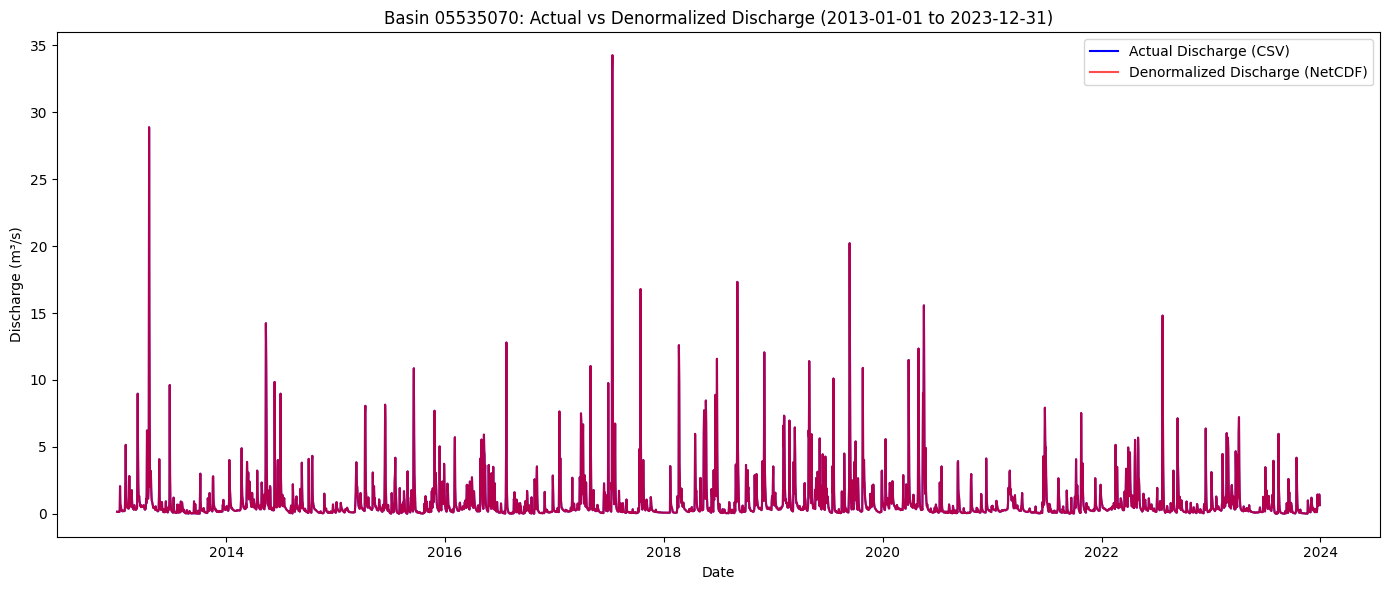

In [14]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
BASIN_ID = '05535070'  # <-- Change this to your basin of interest
CSV_DIR = 'metadata/csv_filtered'
NC_DIR = 'data/time_series'
ATTR_FILE = 'metadata/attributes.csv'
EPSILON = 1e-6
BASIN_AREA_SCALE_DIVISOR = 1000.0
TEST_START_DATE = '2013-01-01'

# Load attributes
attributes_df = pd.read_csv(ATTR_FILE)
attributes_df.set_index('gauge_id', inplace=True)
basin_area = attributes_df.loc[BASIN_ID, 'area']
scaled_basin_area = basin_area / BASIN_AREA_SCALE_DIVISOR

# Use your known global mean/std
global_mean = -11.6949
global_std = 67.8412

# Load NetCDF and CSV
nc_path = os.path.join(NC_DIR, f"{BASIN_ID}.nc")
csv_path = os.path.join(CSV_DIR, f"{BASIN_ID}.csv")
ds = xr.open_dataset(nc_path)
df_nc = ds.to_dataframe().reset_index()
ds.close()
df_csv = pd.read_csv(csv_path, parse_dates=['date'])

# Only compare test period
mask = (df_nc['date'] >= TEST_START_DATE)
df_nc = df_nc[mask].copy()
df_csv = df_csv[df_csv['date'] >= TEST_START_DATE].copy()

# Align by date
df_nc = df_nc.set_index('date')
df_csv = df_csv.set_index('date')
common_dates = df_nc.index.intersection(df_csv.index)
df_nc = df_nc.loc[common_dates]
df_csv = df_csv.loc[common_dates]

# Reverse normalization for discharge
sim = df_nc['discharge'].copy()
sim = (sim * global_std) + global_mean
sim = sim * scaled_basin_area
sim = np.exp(sim) - EPSILON

# Prepare for plotting
actual = df_csv['discharge'].copy()
dates = common_dates

plt.figure(figsize=(14, 6))
plt.plot(dates, actual, label='Actual Discharge (CSV)', color='blue')
plt.plot(dates, sim, label='Denormalized Discharge (NetCDF)', color='red', alpha=0.7)
plt.title(f'Basin {BASIN_ID}: Actual vs Denormalized Discharge (2013-01-01 to 2023-12-31)')
plt.xlabel('Date')
plt.ylabel('Discharge (m³/s)')
plt.legend()
plt.tight_layout()
plt.show()

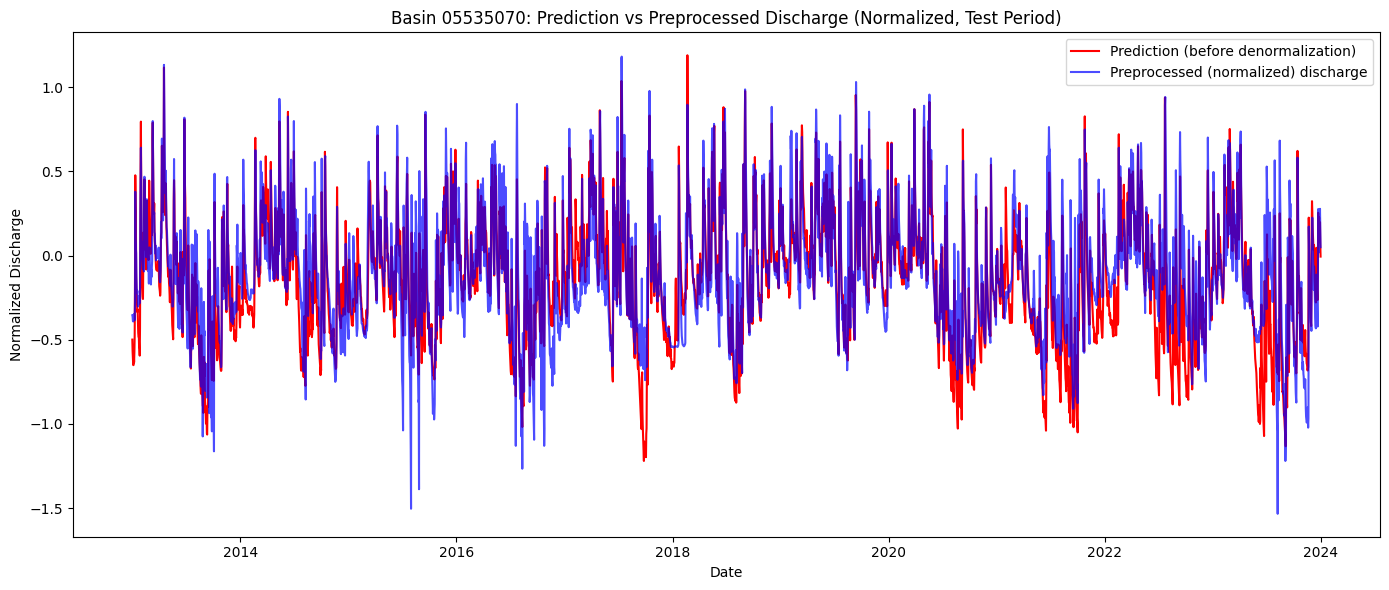

In [16]:
import pickle
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
run_dir = "runs/EA-LSTM_Basin_Normalized_1906_122616"  # <-- Change to your run directory
epoch_num = 42                  # <-- Change to your epoch number
basin_id = '05535070'              # <-- Change to your basin ID
nc_dir = 'data/time_series'
test_start_date = '2013-01-01'
test_end_date = '2023-12-31'

# --- 1. Load predictions (before denormalization) ---
# Find the correct epoch folder
epoch_folder_name = f"model_epoch{epoch_num:03d}"
results_file = Path(run_dir) / "test" / epoch_folder_name / "test_results.p"
if not results_file.exists():
    raise FileNotFoundError(f"Could not find test_results.p at {results_file}")

with open(results_file, "rb") as fp:
    results = pickle.load(fp)

qsim = results[basin_id]['1D']['xr']['discharge_sim']
sim_pred = qsim.values.copy()  # This is BEFORE denormalization
dates_pred = pd.to_datetime(qsim['date'].values)

# --- 2. Load preprocessed (normalized) discharge from NetCDF ---
nc_path = Path(nc_dir) / f"{basin_id}.nc"
ds = xr.open_dataset(nc_path)
df_nc = ds.to_dataframe().reset_index()
ds.close()

# Only test period
mask = (df_nc['date'] >= test_start_date) & (df_nc['date'] <= test_end_date)
df_nc = df_nc[mask].copy()
df_nc = df_nc.set_index('date')

# --- 3. Align by date ---
df_pred = pd.DataFrame({
    'date': np.array(dates_pred).flatten(),
    'predicted': np.array(sim_pred).flatten()
})
df_pred = df_pred[(df_pred['date'] >= test_start_date) & (df_pred['date'] <= test_end_date)]
df_pred = df_pred.set_index('date')

common_dates = df_pred.index.intersection(df_nc.index)
pred_aligned = df_pred.loc[common_dates, 'predicted']
nc_aligned = df_nc.loc[common_dates, 'discharge']

# --- 4. Plot ---
plt.figure(figsize=(14, 6))
plt.plot(common_dates, pred_aligned, label='Prediction (before denormalization)', color='red')
plt.plot(common_dates, nc_aligned, label='Preprocessed (normalized) discharge', color='blue', alpha=0.7)
plt.title(f'Basin {basin_id}: Prediction vs Preprocessed Discharge (Normalized, Test Period)')
plt.xlabel('Date')
plt.ylabel('Normalized Discharge')
plt.legend()
plt.tight_layout()
plt.show()

## Load Model

In [ ]:
from util.Evaluator import Evaluator

model_dir = "EA-LSTM_Basin_Normalized_1906_122616" # Specify the model name
epoch_num = 42 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/test.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=-11.6949,
                      var=67.8412,
                      apply_transformation=True,
                      attributes_file="metadata/attributes.csv")

  0%|          | 0/975 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/975 [00:00<03:32,  4.59it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

KeyboardInterrupt: 

In [6]:
print(evaluator)

Summary for: evaluate EA-LSTM_Basin_Normalized_1906_122616 epoch 42

NSE Summary Statistics: 
count    647.000000
mean      -2.608002
std       24.249595
min     -598.342020
25%       -1.191993
50%       -0.556487
75%       -0.204568
max        0.151991
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    580.000000
mean      -0.440754
std        0.513434
min       -6.791843
25%       -0.452665
50%       -0.431053
75%       -0.306652
max        0.087244
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Negative          588
N/A               328
Unsatisfactory     59
Name: count, dtype: int64

evaluate EA-LSTM_Basin_Normalized_1906_122616 epoch 42


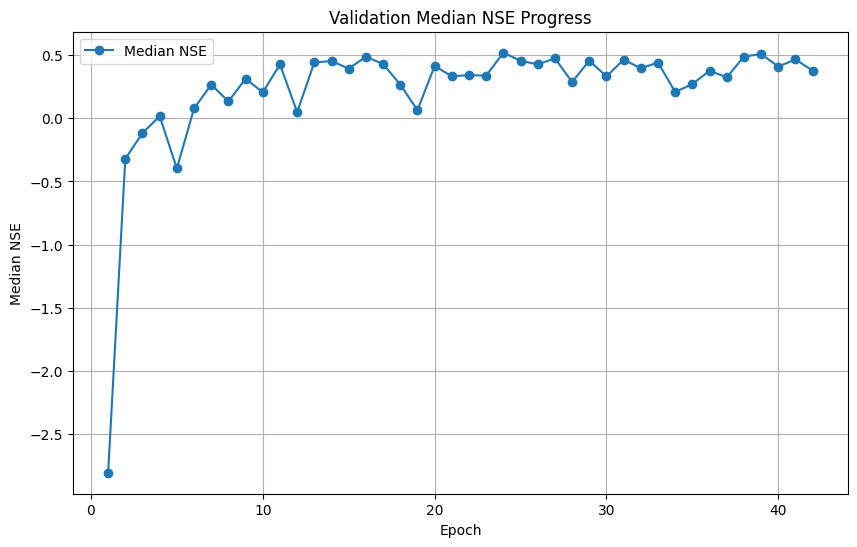

In [9]:
evaluator.plot_validation()

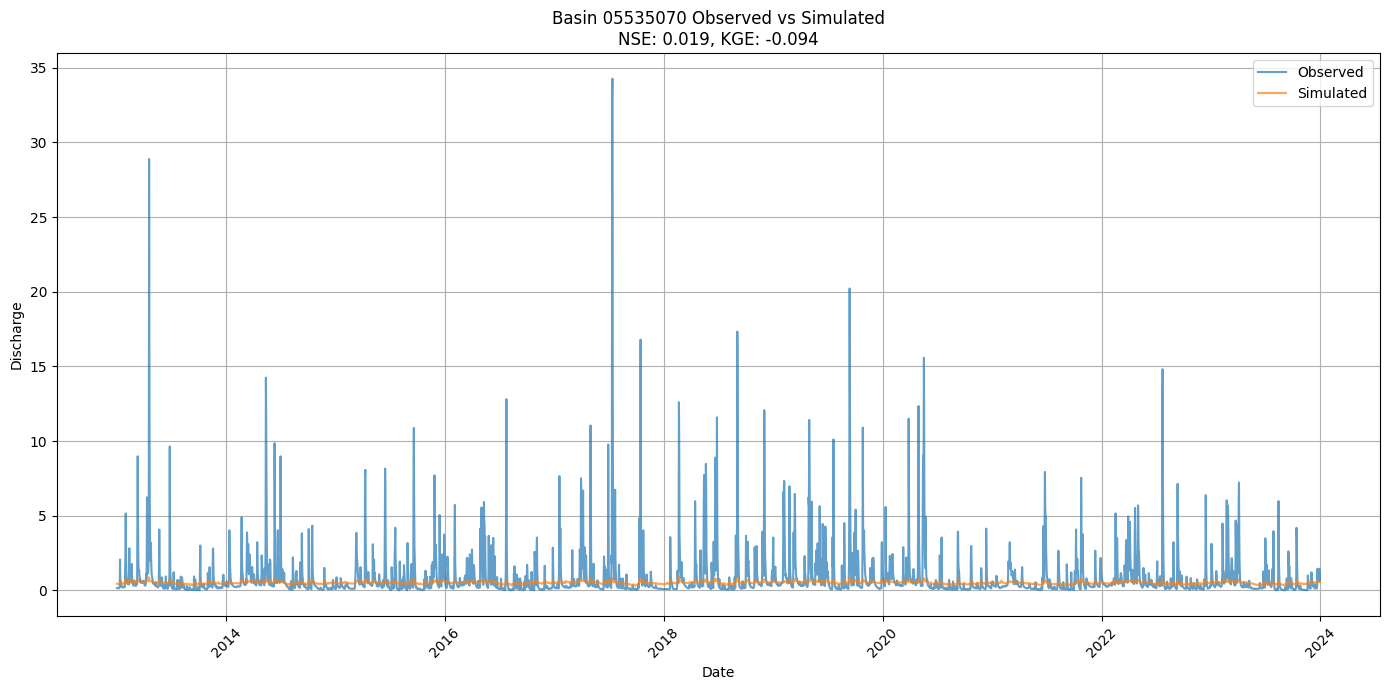

In [ ]:
evaluator.plot_prediction("05535070")

In [10]:
nse, kge, preds, obs, dates = evaluator.get_prediction("05535070")

In [23]:
preds = pd.Series(preds)
print(preds.describe())

count    4017.000000
mean        0.517313
std         0.079321
min         0.325738
25%         0.460537
50%         0.512778
75%         0.565957
max         0.907104
dtype: float64


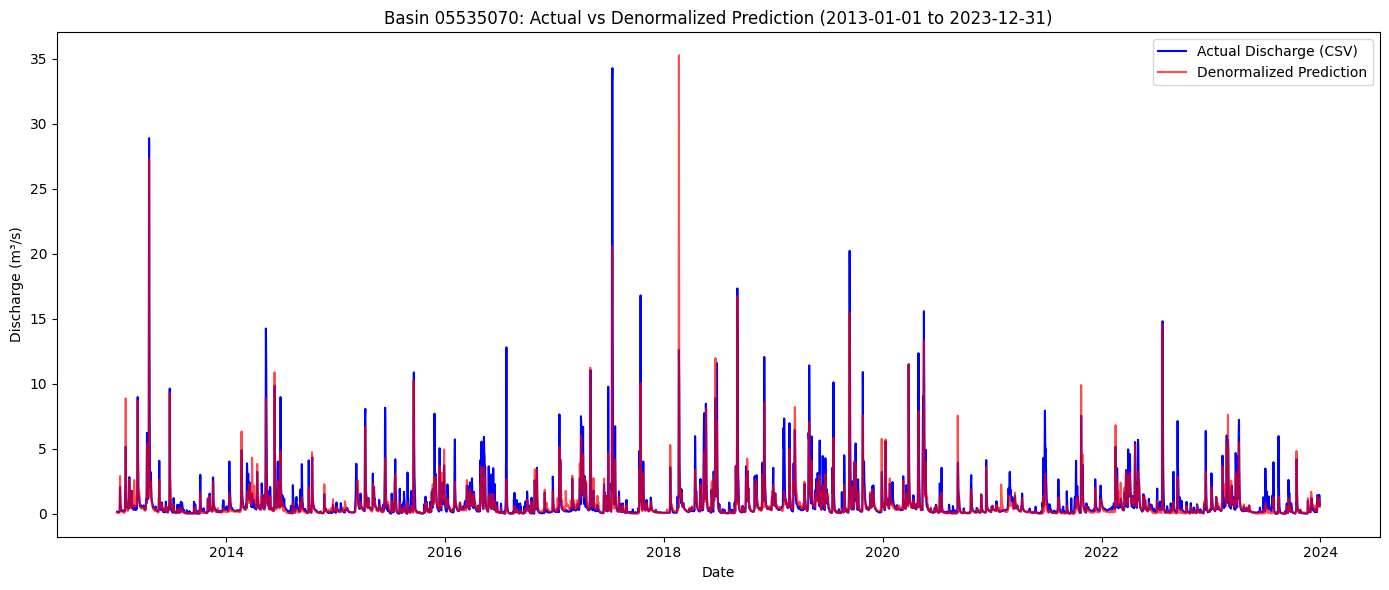

In [4]:
import os
import pickle
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
BASIN_ID = '05535070'
RUN_DIR = "runs/EA-LSTM_Basin_Normalized_1906_122616"
EPOCH_NUM = 42
CSV_DIR = 'metadata/csv_filtered'
ATTR_FILE = 'metadata/attributes.csv'
EPSILON = 1e-6
BASIN_AREA_SCALE_DIVISOR = 1000.0
TEST_START_DATE = '2013-01-01'
TEST_END_DATE = '2023-12-31'

# Load attributes
attributes_df = pd.read_csv(ATTR_FILE)
attributes_df.set_index('gauge_id', inplace=True)
basin_area = attributes_df.loc[BASIN_ID, 'area']
scaled_basin_area = basin_area / BASIN_AREA_SCALE_DIVISOR

# Use your known global mean/std
global_mean = -11.6949
global_std = 67.8412

# --- Load predictions (before denormalization) ---
epoch_folder_name = f"model_epoch{EPOCH_NUM:03d}"
results_file = Path(RUN_DIR) / "test" / epoch_folder_name / "test_results.p"
if not results_file.exists():
    raise FileNotFoundError(f"Could not find test_results.p at {results_file}")

with open(results_file, "rb") as fp:
    results = pickle.load(fp)

qsim = results[BASIN_ID]['1D']['xr']['discharge_sim']
sim_pred = np.array(qsim.values).flatten()  # Ensure 1D
dates_pred = pd.to_datetime(qsim['date'].values)

# --- Load actual discharge from CSV ---
csv_path = os.path.join(CSV_DIR, f"{BASIN_ID}.csv")
df_csv = pd.read_csv(csv_path, parse_dates=['date'])
df_csv = df_csv[df_csv['date'] >= TEST_START_DATE]
df_csv = df_csv[df_csv['date'] <= TEST_END_DATE]
df_csv = df_csv.set_index('date')

# --- Align by date ---
df_pred = pd.DataFrame({'date': dates_pred, 'predicted': sim_pred})
df_pred = df_pred[(df_pred['date'] >= TEST_START_DATE) & (df_pred['date'] <= TEST_END_DATE)]
df_pred = df_pred.set_index('date')

common_dates = df_pred.index.intersection(df_csv.index)
pred_aligned = df_pred.loc[common_dates, 'predicted']
actual_aligned = df_csv.loc[common_dates, 'discharge']

# --- Denormalize predictions ---
sim = pred_aligned.copy()
sim = (sim * global_std) + global_mean
sim = sim * scaled_basin_area
sim = np.exp(sim) - EPSILON

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.plot(common_dates, actual_aligned, label='Actual Discharge (CSV)', color='blue')
plt.plot(common_dates, sim, label='Denormalized Prediction', color='red', alpha=0.7)
plt.title(f'Basin {BASIN_ID}: Actual vs Denormalized Prediction (2013-01-01 to 2023-12-31)')
plt.xlabel('Date')
plt.ylabel('Discharge (m³/s)')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
print(sim.describe())

count    4017.000000
mean        0.695050
std         1.394267
min         0.007650
25%         0.132570
50%         0.321225
75%         0.724066
max        35.256039
Name: predicted, dtype: float64


## Plot the validation curve to possibly identify overfitting

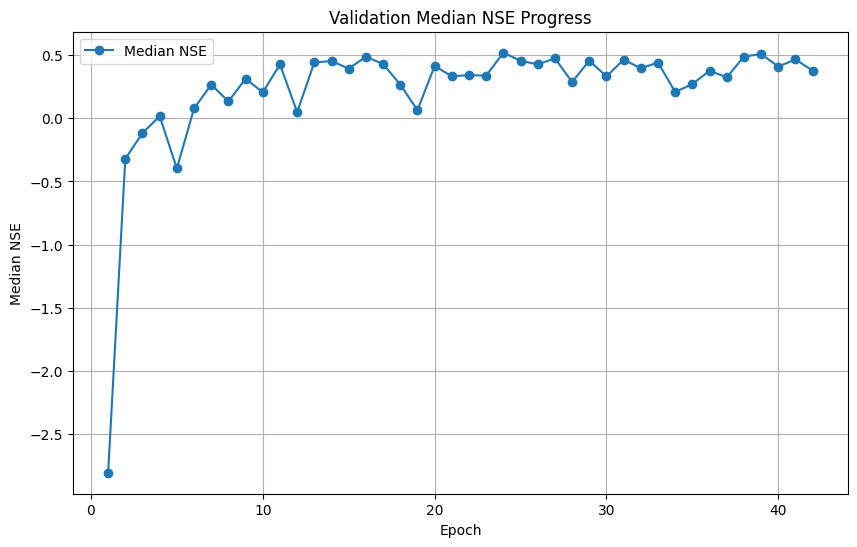

In [11]:
evaluator.plot_validation("Median")

## Evaluation Results

In [32]:
print(evaluator)

Summary Statistic: 
count    6.470000e+02
mean    -3.299132e+60
std      8.391736e+61
min     -2.134538e+63
25%      1.839860e-01
50%      5.036016e-01
75%      6.457838e-01
max      8.590568e-01
Name: NSE, dtype: float64

Performance Summary: 
Performance
Negative          455
Good              378
Unsatisfactory    102
Excellent          40
Name: count, dtype: int64

evaluate GAGEii-ALL_Gauges_Filtered_Periodically_eslstm_1303_085231 epoch 17


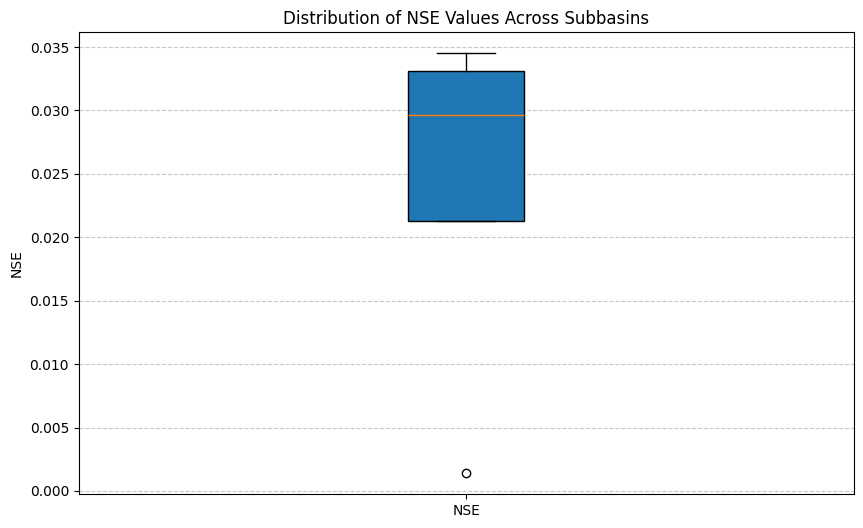

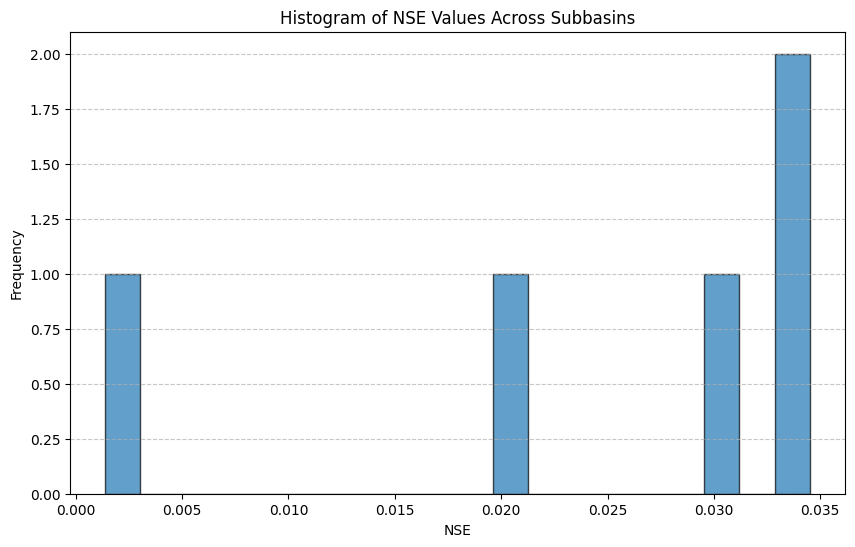

In [12]:
evaluator.plot_nse_distribution()

## Scatterplot of NSE vs Coverage

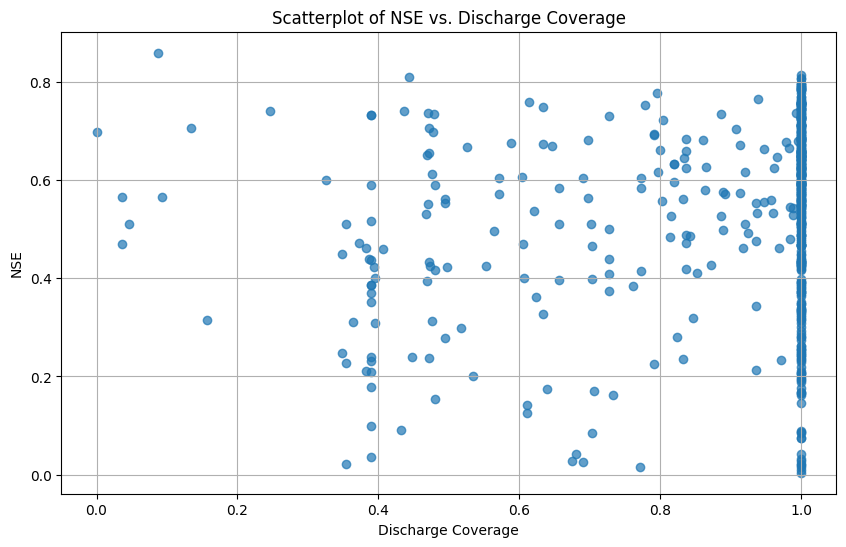

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

nse_df = evaluator.get_nse()
nse_df_filtered = nse_df[nse_df["NSE"] > 0]
coverage_df = pd.read_csv("metadata/coverage.csv")

# Merge the two dataframes on 'basin_id'
merged_df = pd.merge(nse_df_filtered, coverage_df, on="basin_id", how="inner")

# Create the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(merged_df["discharge_coverage"], merged_df["NSE"], alpha=0.7)
plt.xlabel("Discharge Coverage")
plt.ylabel("NSE")
plt.title("Scatterplot of NSE vs. Discharge Coverage")
plt.grid(True)
plt.show()

In [35]:
nse_df_filtered.describe()

,NSE
count,520.000000
mean,0.522116
std,0.191528
min,0.003950
25%,0.415344
50%,0.565521
75%,0.663759
max,0.859057


In [36]:
nse_df.to_csv("result.csv")

## LBRM

In [1]:
from util.Evaluator import Evaluator

model_dir = "EA-LSTM_LowerLearningRate_0404_074727" # Specify the model name
epoch_num = 18 # Specify the epoch number
eval_dir = "metadata/LBRM_daymet" # Directory to the csv files for evaluation
eval_list = "basin_list/LBRM.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=3.2232695112217513,
                      var=5.16634650602,
                      apply_transformation=True,)

100%|██████████| 94/94 [00:03<00:00, 26.98it/s]


In [2]:
print(evaluator)

Summary Statistic: 
count    92.000000
mean     -1.502138
std       3.380067
min     -25.956634
25%      -1.315034
50%      -0.561532
75%      -0.252976
max       0.011691
Name: NSE, dtype: float64

Summary Statistic: 
count    92.000000
mean     -0.887093
std       0.984982
min      -9.560673
25%      -0.835892
50%      -0.775811
75%      -0.734667
max      -0.278567
Name: KGE, dtype: float64

Performance Summary: 
Performance
Negative          90
Unsatisfactory     2
N/A                2
Name: count, dtype: int64

evaluate EA-LSTM_LowerLearningRate_0404_074727 epoch 18


In [3]:
evaluator.get_prediction("eri01")

(-0.6173083888252777,
 -0.6699818040452516,
 array([40.404465, 40.404503, 40.404526, ..., 31.95427 , 31.965675,
        31.860813], dtype=float32))

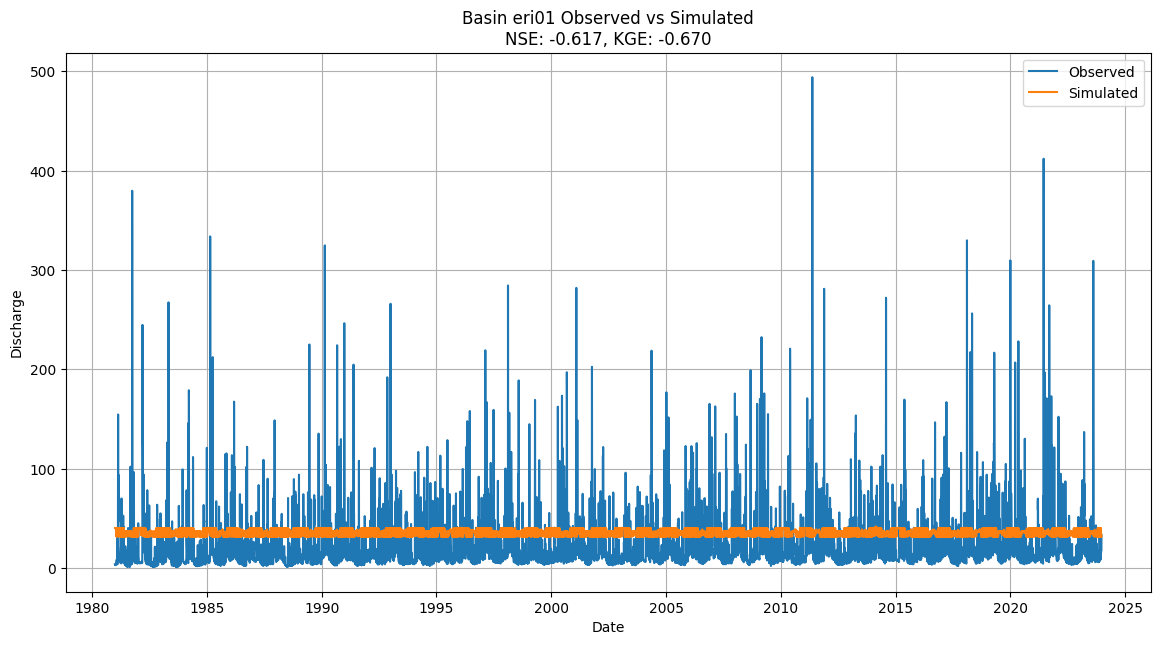

In [4]:
evaluator.plot_prediction("eri01")

In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

csv_dir = Path("metadata/LBRM_daymet")
csv_files = list(csv_dir.glob("*.csv"))

for csv_file in tqdm(csv_files, desc="Renaming 'Date' to 'date' in CSVs"):
    try:
        df = pd.read_csv(csv_file)
        if "Date" in df.columns:
            df.rename(columns={"Date": "date"}, inplace=True)
            df.to_csv(csv_file, index=False)
    except Exception as e:
        print(f"Error processing {csv_file.name}: {e}")

Renaming 'Date' to 'date' in CSVs: 100%|██████████| 121/121 [00:07<00:00, 16.84it/s]
